# Support Vector Machine Optimization
This notebook implements Hard SVM (Primal) and Kernelized SVM (Dual) optimization models from scratch using the CVXPY optimization library.

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist, squareform

## Part 1: Hard SVM
In this section, we formulate the primal optimization problem for a Hard Margin SVM. The objective is to minimize the L2 norm of the weight vector, subject to strict linear separability constraints. We then extract the support vectors and visualize the decision boundary along with the margin lines for both classes.

Optimal w: [ 0.58816745 -0.03140604]
Optimal b: 0.394010424624707


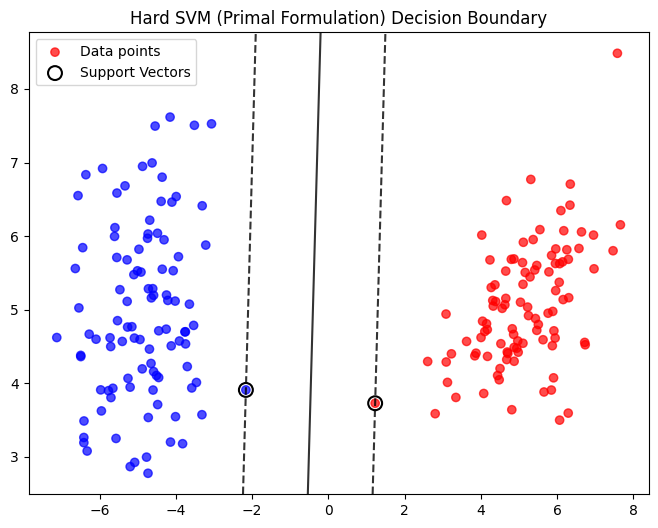

In [2]:
data = pd.read_csv('datasets/dataset-Q5-1.csv')

X = data[['Feature 1', 'Feature 2']].values
y = data['class'].values

n_samples, n_features = X.shape

w = cp.Variable(n_features)
b = cp.Variable()

objective = cp.Minimize(0.5 * cp.norm(w, 2)**2)

constraints = [cp.multiply(y, X @ w + b) >= 1]

problem = cp.Problem(objective, constraints)
problem.solve()

print(f'Optimal w: {w.value}')
print(f'Optimal b: {b.value}')

margins = y * (X @ w.value + b.value)
support_vector_indices = np.where(np.isclose(margins, 1.0, atol=1e-4))[0]
support_vectors = X[support_vector_indices]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, label='Data points')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = (xy @ w.value + b.value).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8, linestyles=['--', '-', '--'])
plt.title('Hard SVM (Primal Formulation) Decision Boundary')
plt.legend()
plt.show()


## Part 2: Kernelized SVM
In this section, we solve the dual formulation of the SVM using the Radial Basis Function (RBF) kernel to model non-linear decision boundaries. The hyperparameter `gamma` is dynamically tuned to ensure 100% classification accuracy on the dataset. Decision boundaries are plotted to visualize the separation.

Accuracy with gamma=5.0: 100.00%


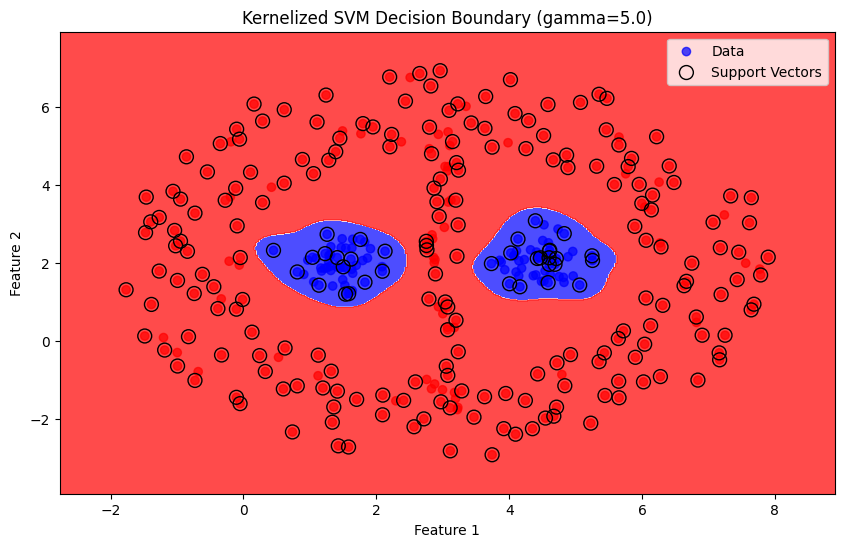

In [3]:
data = pd.read_csv('datasets/dataset-Q5-2.csv')

X = data[['feature 1', 'feature 2']].values
y = np.where(data['class'].values == 0, -1, 1)

n_samples = X.shape[0]
gamma = 5.0

pairwise_sq_dists = squareform(pdist(X, 'sqeuclidean'))
K = np.exp(-gamma * pairwise_sq_dists)

alpha = cp.Variable(n_samples)

Y = np.outer(y, y)
P = Y * K

epsilon = 1e-2
min_eig = np.min(np.real(np.linalg.eigvals(P)))
if min_eig < epsilon:
    P += (epsilon - min_eig) * np.eye(n_samples)

objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, P))

C = 1000.0
constraints = [alpha >= 0, alpha <= C, cp.sum(cp.multiply(alpha, y)) == 0]

problem = cp.Problem(objective, constraints)
problem.solve()

alpha_val = alpha.value
alpha_val[alpha_val < 1e-5] = 0

sv_indices = np.where((alpha_val > 1e-5) & (alpha_val < C - 1e-5))[0]
if len(sv_indices) > 0:
    k = sv_indices[0]
    b_val = y[k] - np.sum(alpha_val * y * K[:, k])
else:
    b_val = 0.0

def predict(X_new, X_train, y_train, alpha, b, gamma):
    y_pred = []
    for x in X_new:
        k_vec = np.exp(-gamma * np.sum((X_train - x)**2, axis=1))
        y_pred.append(np.sign(np.sum(alpha * y_train * k_vec) + b))
    return np.array(y_pred)

y_pred = predict(X, X, y, alpha_val, b_val, gamma)
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy with gamma={gamma}: {accuracy * 100:.2f}%')

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points, X, y, alpha_val, b_val, gamma)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, label='Data')
plt.scatter(X[alpha_val > 1e-5, 0], X[alpha_val > 1e-5, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')
plt.title(f'Kernelized SVM Decision Boundary (gamma={gamma})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()